# notebook for NAO index


In [23]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from process_raw_data import process_data, decimal_year_to_datetime


In [2]:

nao_file = "nao/norm.nao.monthly.b5001.current.ascii.table"

df = pd.read_csv(nao_file, sep=r"\s+")
df.index.name = "year"

time = pd.to_datetime(
    [f"{year}-{month}" 
     for year in df.index 
     for month in df.columns]
)

# Flatten the values in the same order
values = df.values.flatten()

nao = xr.DataArray(
    values,
    dims="time",
    coords={"time": time},
    name="NAO"
)

/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_3731/3142171710.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time = pd.to_datetime(


In [3]:

## change time to match with calafat timestamp
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")
ds["time"] = decimal_year_to_datetime(ds.time.values)

first_time = ds.time.values[0]
last_time = ds.time.values[-1]
print(first_time)
print(last_time)

2004-02-14T23:59:59.999997
2020-08-14T23:59:59.999998


In [4]:
# quarterly resample
nao_quarterly = nao.resample(time="QE-FEB").mean()

# Subset to roughly the ds time range (with a little buffer)
nao_quarterly = nao_quarterly.sel(
    time=slice(pd.Timestamp(ds.time.values[0]) - pd.DateOffset(months=1),
               pd.Timestamp(ds.time.values[-1]) + pd.DateOffset(months=1))
)

# 3. Align exactly onto ds time stamps 
nao_quarterly = nao_quarterly.reindex(time=ds.time.values, method="nearest", tolerance="20D")

print(len(nao_quarterly), len(ds.time))  # sanity check they match

67 67


In [20]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})


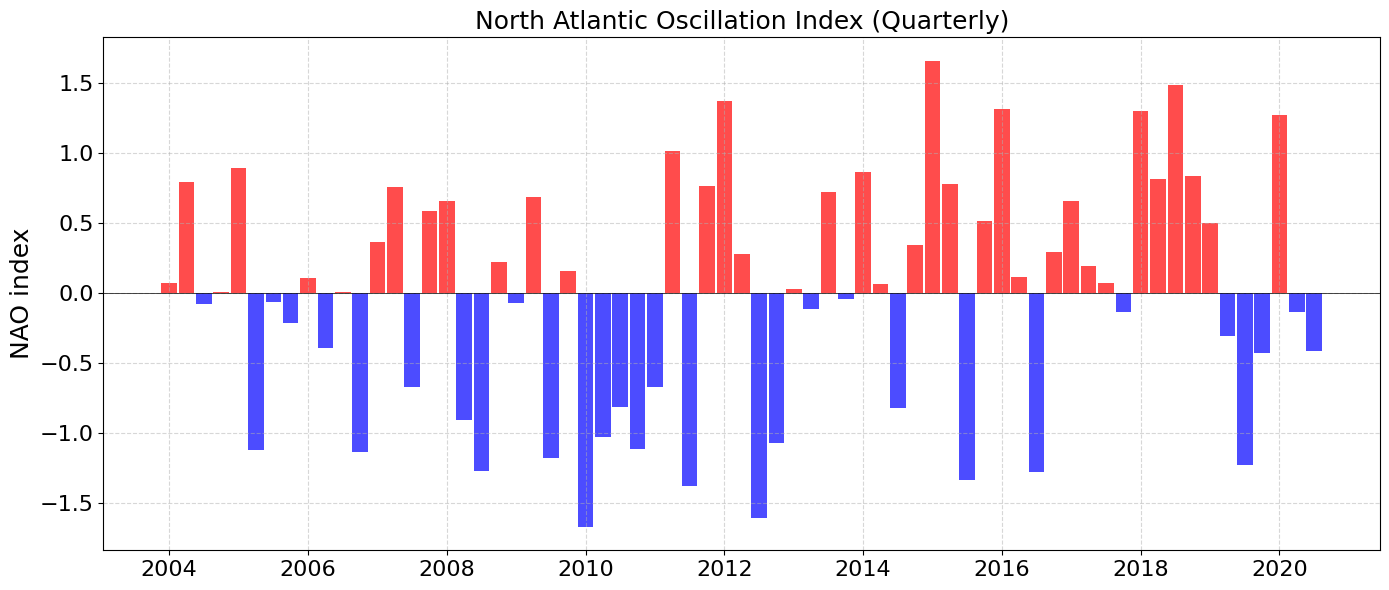

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(nao_quarterly.time))
colors = ["red" if v > 0 else "blue" for v in nao_quarterly.values]

ax.bar(x, nao_quarterly.values, color=colors, width=0.9, alpha=0.7)

ax.axhline(0, color="black", linewidth=0.5)


ax.set_ylabel("NAO index")
# ax.set_xlabel("Year")
ax.set_title("North Atlantic Oscillation Index (Quarterly)")
ax.grid(alpha=0.5, linestyle="--")

years = pd.to_datetime(nao_quarterly.time.values).year  
tick_idx = np.arange(0, len(x), 8)
ax.set_xticks(tick_idx)
ax.set_xticklabels(years[tick_idx])

    
plt.tight_layout()
plt.show()